# 웨이퍼 모델링 실험

위에서부터 실행합니다. Python 모듈은 Google Drive의 `wafer_v2/modeling`에 두세요. 후보 선택은 validation으로만 수행하며 마지막 단계만 test를 평가합니다. 총 고유 학습은 11회입니다.

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/SKALA/wafer_v2")

# Colab 런타임에서 Drive를 연결한다.
if not PROJECT_ROOT.exists():
    from google.colab import drive

    drive.mount("/content/drive")

if not (PROJECT_ROOT / "modeling" / "training.py").is_file():
    raise FileNotFoundError(
        f"modeling 코드를 Drive에 복사하세요: {PROJECT_ROOT}"
    )
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

Mounted at /content/drive


## 환경 준비

Colab GPU 런타임을 선택하세요. 아래 셀은 필요한 패키지만 설치하며 기존 torch를 강제로 업그레이드하지 않습니다. 설치 후 import 오류가 있으면 커널을 다시 시작하세요.

In [3]:
%pip install -r "$PROJECT_ROOT/modeling/requirements.txt"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 MB 16.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93


In [4]:
import pandas as pd
import torch
from IPython.display import Image, display

from modeling.config import ExperimentConfig, code_version, read_json
from modeling.data import create_or_load_splits, load_dataset
from modeling.evaluation import get_experiment_status, load_experiment_results
from modeling.run_experiment import run_stage
from modeling.training import configure_logging

configure_logging()
DATA_PATH = PROJECT_ROOT / "data" / "LSWMD.pkl"
ARTIFACT_ROOT = PROJECT_ROOT / "modeling" / "artifacts"
BASE_CONFIG = ExperimentConfig(epochs=30, batch_size=32)
print(
    "장치:",
    torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
)
if not torch.cuda.is_available():
    raise RuntimeError("실제 실험에는 Colab GPU 런타임을 선택하세요.")

frame = load_dataset(DATA_PATH)
splits = create_or_load_splits(frame, ARTIFACT_ROOT)
del frame
print("분할 ID:", splits.split_id)

장치: Tesla T4
2026-09-09 04:11:35,600 | INFO | 데이터 로딩 시작: /content/drive/MyDrive/Colab Notebooks/SKALA/wafer_v2/data/LSWMD.pkl
2026-09-09 04:12:58,344 | INFO | 데이터 로딩 완료: 172950행, 82.7초
2026-09-09 04:12:58,345 | INFO | 데이터 지문 및 고정 분할 준비 시작


분할: 데이터 지문:   0%|          | 0/172950 [00:00<?, ?it/s]

2026-09-09 04:13:02,684 | INFO | 고정 분할 재사용: /content/drive/MyDrive/Colab Notebooks/SKALA/wafer_v2/modeling/artifacts/splits/6d6595422539596b6a673e4108875f03cfa99063d6e6064f66678f6af737cfa1.json
2026-09-09 04:13:02,903 | INFO | train: 138360행, 분포={'none': 117945, 'Edge-Ring': 7744, 'Edge-Loc': 4151, 'Center': 3435, 'Loc': 2875, 'Scratch': 954, 'Random': 693, 'Donut': 444, 'Near-full': 119}
2026-09-09 04:13:02,908 | INFO | validation: 17295행, 분포={'none': 14743, 'Edge-Ring': 968, 'Edge-Loc': 519, 'Center': 429, 'Loc': 359, 'Scratch': 120, 'Random': 86, 'Donut': 56, 'Near-full': 15}
2026-09-09 04:13:02,914 | INFO | test: 17295행, 분포={'none': 14743, 'Edge-Ring': 968, 'Edge-Loc': 519, 'Center': 430, 'Loc': 359, 'Scratch': 119, 'Random': 87, 'Donut': 55, 'Near-full': 15}
2026-09-09 04:13:02,969 | INFO | 분할 완료: 6d6595422539, train/validation 중복 Lot 수=6790
분할 ID: 6d6595422539596b6a673e4108875f03cfa99063d6e6064f66678f6af737cfa1


## 1. 모델 비교 — 신규 학습 4회

Fixed + Weighted CE + 증강 없음으로 SmallCNN, SpatialCNN, ResidualCNN, HybridCNN을 비교합니다. 모든 후보는 최대 30 epoch, early stopping patience 7입니다.

In [ ]:
model_paths = run_stage("models", splits, ARTIFACT_ROOT, BASE_CONFIG)

2026-09-09 00:33:49,127 | INFO | 단계=models 후보=1/4 고유 학습 완료=10/11 현재=small_cnn_17488d1a4881
2026-09-09 00:33:50,255 | INFO | 완료 실험 재사용: small_cnn_17488d1a4881
2026-09-09 00:33:50,739 | INFO | 고유 학습 완료=10/11
2026-09-09 00:33:50,772 | INFO | 단계=models 후보=2/4 고유 학습 완료=10/11 현재=spatial_cnn_eaa6f09b055c
2026-09-09 00:33:51,861 | INFO | 완료 실험 재사용: spatial_cnn_eaa6f09b055c
2026-09-09 00:33:52,458 | INFO | 고유 학습 완료=10/11
2026-09-09 00:33:52,500 | INFO | 단계=models 후보=3/4 고유 학습 완료=10/11 현재=residual_cnn_8123daeff8cd
2026-09-09 00:33:53,895 | INFO | 완료 실험 재사용: residual_cnn_8123daeff8cd
2026-09-09 00:33:54,384 | INFO | 고유 학습 완료=10/11
2026-09-09 00:33:54,398 | INFO | 단계=models 후보=4/4 고유 학습 완료=10/11 현재=hybrid_cnn_3b52190d3bbe
2026-09-09 00:33:55,496 | INFO | 완료 실험 재사용: hybrid_cnn_3b52190d3bbe
2026-09-09 00:33:55,915 | INFO | 고유 학습 완료=10/11


In [ ]:
results = load_experiment_results(ARTIFACT_ROOT)
display(
    results[
        results.experiment_id.isin([p.name for p in model_paths])
    ].sort_values("validation_macro_f1", ascending=False)
)

,experiment_id,model,preprocessing,loss,augmentation,seed,target_size,epochs,batch_size,learning_rate,weight_decay,scheduler_patience,early_stopping_patience,num_workers,split_id,code_version,validation_macro_f1,worst_class_f1,parameters,best_epoch
4,residual_cnn_8123daeff8cd,residual_cnn,fixed_resize,weighted_ce,False,42,64,30,32,0.001,0.0001,3,7,0,6d6595422539596b6a673e4108875f03cfa99063d6e606...,6131e5b47165f7487436ebf3a1573276acab4a16966ce6...,0.877607,0.773154,548361,15
9,spatial_cnn_eaa6f09b055c,spatial_cnn,fixed_resize,weighted_ce,False,42,64,30,32,0.001,0.0001,3,7,0,6d6595422539596b6a673e4108875f03cfa99063d6e606...,6131e5b47165f7487436ebf3a1573276acab4a16966ce6...,0.873378,0.750378,521161,16
0,hybrid_cnn_3b52190d3bbe,hybrid_cnn,fixed_resize,weighted_ce,False,42,64,30,32,0.001,0.0001,3,7,0,6d6595422539596b6a673e4108875f03cfa99063d6e606...,6131e5b47165f7487436ebf3a1573276acab4a16966ce6...,0.863326,0.753501,522249,11
8,small_cnn_17488d1a4881,small_cnn,fixed_resize,weighted_ce,False,42,64,30,32,0.001,0.0001,3,7,0,6d6595422539596b6a673e4108875f03cfa99063d6e606...,6131e5b47165f7487436ebf3a1573276acab4a16966ce6...,0.858247,0.716253,391113,25


## 2. 학습법 비교 — 신규 학습 3회

우승 모델에서 CE/Weighted CE × 증강 유무 4조건을 비교합니다. 기존 Weighted CE + 증강 없음 결과 1개는 재사용합니다.

In [ ]:
recipe_paths = run_stage("recipes", splits, ARTIFACT_ROOT, BASE_CONFIG)

2026-09-09 00:34:06,941 | INFO | 단계=recipes 후보=1/4 고유 학습 완료=10/11 현재=residual_cnn_e19d7dd38d6c
2026-09-09 00:34:06,975 | INFO | 완료 실험 재사용: residual_cnn_e19d7dd38d6c
2026-09-09 00:34:07,325 | INFO | 고유 학습 완료=10/11
2026-09-09 00:34:07,339 | INFO | 단계=recipes 후보=2/4 고유 학습 완료=10/11 현재=residual_cnn_345f6ea69a42
2026-09-09 00:34:07,361 | INFO | 완료 실험 재사용: residual_cnn_345f6ea69a42
2026-09-09 00:34:08,043 | INFO | 고유 학습 완료=10/11
2026-09-09 00:34:08,056 | INFO | 단계=recipes 후보=3/4 고유 학습 완료=10/11 현재=residual_cnn_8123daeff8cd
2026-09-09 00:34:08,077 | INFO | 완료 실험 재사용: residual_cnn_8123daeff8cd
2026-09-09 00:34:08,090 | INFO | 고유 학습 완료=10/11
2026-09-09 00:34:08,103 | INFO | 단계=recipes 후보=4/4 고유 학습 완료=10/11 현재=residual_cnn_ff67addb590f
2026-09-09 00:34:08,125 | INFO | 완료 실험 재사용: residual_cnn_ff67addb590f
2026-09-09 00:34:08,460 | INFO | 고유 학습 완료=10/11


In [ ]:
results = load_experiment_results(ARTIFACT_ROOT)
display(
    results[
        results.experiment_id.isin([p.name for p in recipe_paths])
    ].sort_values("validation_macro_f1", ascending=False)
)

,experiment_id,model,preprocessing,loss,augmentation,seed,target_size,epochs,batch_size,learning_rate,weight_decay,scheduler_patience,early_stopping_patience,num_workers,split_id,code_version,validation_macro_f1,worst_class_f1,parameters,best_epoch
5,residual_cnn_e19d7dd38d6c,residual_cnn,fixed_resize,ce,False,42,64,30,32,0.001,0.0001,3,7,0,6d6595422539596b6a673e4108875f03cfa99063d6e606...,6131e5b47165f7487436ebf3a1573276acab4a16966ce6...,0.880433,0.747024,548361,26
4,residual_cnn_8123daeff8cd,residual_cnn,fixed_resize,weighted_ce,False,42,64,30,32,0.001,0.0001,3,7,0,6d6595422539596b6a673e4108875f03cfa99063d6e606...,6131e5b47165f7487436ebf3a1573276acab4a16966ce6...,0.877607,0.773154,548361,15
7,residual_cnn_ff67addb590f,residual_cnn,fixed_resize,weighted_ce,True,42,64,30,32,0.001,0.0001,3,7,0,6d6595422539596b6a673e4108875f03cfa99063d6e606...,6131e5b47165f7487436ebf3a1573276acab4a16966ce6...,0.874333,0.751773,548361,23
1,residual_cnn_345f6ea69a42,residual_cnn,fixed_resize,ce,True,42,64,30,32,0.001,0.0001,3,7,0,6d6595422539596b6a673e4108875f03cfa99063d6e606...,6131e5b47165f7487436ebf3a1573276acab4a16966ce6...,0.866679,0.746988,548361,21


## 3. 전처리 비교 — 신규 학습 2회

우승 모델·학습법에서 Fixed, Pad, Pad+Mask를 비교합니다. 기존 Fixed 결과 1개는 재사용합니다.

In [ ]:
preprocessing_paths = run_stage(
    "preprocessing", splits, ARTIFACT_ROOT, BASE_CONFIG
)

2026-09-09 00:34:08,814 | INFO | 단계=preprocessing 후보=1/3 고유 학습 완료=10/11 현재=residual_cnn_e19d7dd38d6c
2026-09-09 00:34:08,848 | INFO | 완료 실험 재사용: residual_cnn_e19d7dd38d6c
2026-09-09 00:34:08,862 | INFO | 고유 학습 완료=10/11
2026-09-09 00:34:08,875 | INFO | 단계=preprocessing 후보=2/3 고유 학습 완료=10/11 현재=residual_cnn_483f70e6ae86
2026-09-09 00:34:08,898 | INFO | 완료 실험 재사용: residual_cnn_483f70e6ae86
2026-09-09 00:34:09,355 | INFO | 고유 학습 완료=10/11
2026-09-09 00:34:09,368 | INFO | 단계=preprocessing 후보=3/3 고유 학습 완료=10/11 현재=residual_cnn_4f3752a9111c
2026-09-09 00:34:09,393 | INFO | 완료 실험 재사용: residual_cnn_4f3752a9111c
2026-09-09 00:34:09,778 | INFO | 고유 학습 완료=10/11


In [ ]:
results = load_experiment_results(ARTIFACT_ROOT)
display(
    results[
        results.experiment_id.isin([p.name for p in preprocessing_paths])
    ].sort_values("validation_macro_f1", ascending=False)
)

,experiment_id,model,preprocessing,loss,augmentation,seed,target_size,epochs,batch_size,learning_rate,weight_decay,scheduler_patience,early_stopping_patience,num_workers,split_id,code_version,validation_macro_f1,worst_class_f1,parameters,best_epoch
2,residual_cnn_483f70e6ae86,residual_cnn,resize_pad,ce,False,42,64,30,32,0.001,0.0001,3,7,0,6d6595422539596b6a673e4108875f03cfa99063d6e606...,6131e5b47165f7487436ebf3a1573276acab4a16966ce6...,0.885084,0.768095,548361,30
5,residual_cnn_e19d7dd38d6c,residual_cnn,fixed_resize,ce,False,42,64,30,32,0.001,0.0001,3,7,0,6d6595422539596b6a673e4108875f03cfa99063d6e606...,6131e5b47165f7487436ebf3a1573276acab4a16966ce6...,0.880433,0.747024,548361,26
3,residual_cnn_4f3752a9111c,residual_cnn,resize_pad_mask,ce,False,42,64,30,32,0.001,0.0001,3,7,0,6d6595422539596b6a673e4108875f03cfa99063d6e606...,6131e5b47165f7487436ebf3a1573276acab4a16966ce6...,0.858064,0.723926,548649,15


## 4. 최종 3-seed 검증 — 신규 학습 2회

이 셀부터 test를 사용합니다. 최종 설정을 고정한 뒤 실행하세요. seed 42를 재사용하고 43·44를 학습합니다. test 결과를 본 뒤 후보 선택을 반복하지 않습니다.

In [12]:
final_paths = run_stage("final", splits, ARTIFACT_ROOT, BASE_CONFIG)

2026-09-09 01:24:10,413 | INFO | 단계=final 후보=1/3 고유 학습 완료=10/11 현재=residual_cnn_483f70e6ae86
2026-09-09 01:24:10,437 | INFO | 완료 실험 재사용: residual_cnn_483f70e6ae86
2026-09-09 01:24:10,451 | INFO | 고유 학습 완료=10/11
2026-09-09 01:24:10,466 | INFO | 단계=final 후보=2/3 고유 학습 완료=10/11 현재=residual_cnn_f04cf821e332
2026-09-09 01:24:10,489 | INFO | 완료 실험 재사용: residual_cnn_f04cf821e332
2026-09-09 01:24:10,511 | INFO | 고유 학습 완료=10/11
2026-09-09 01:24:10,525 | INFO | 단계=final 후보=3/3 고유 학습 완료=10/11 현재=residual_cnn_74e3d27b97f5
2026-09-09 01:24:10,592 | INFO | 단계=final 실험=residual_cnn_74e3d27b97f5 설정={'model': 'residual_cnn', 'preprocessing': 'resize_pad', 'loss': 'ce', 'augmentation': False, 'seed': 44, 'target_size': 64, 'epochs': 30, 'batch_size': 32, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'scheduler_patience': 3, 'early_stopping_patience': 7, 'num_workers': 0}
2026-09-09 01:24:10,594 | INFO | 장치=cuda GPU=Tesla T4 저장=/content/drive/MyDrive/Colab Notebooks/SKALA/wafer_v2/modeling/artifacts/res

전처리·특징 준비:   0%|          | 0/138360 [00:00<?, ?it/s]

2026-09-09 01:24:28,234 | INFO | validation 전처리·특징 준비 시작


전처리·특징 준비:   0%|          | 0/17295 [00:00<?, ?it/s]

2026-09-09 01:24:29,876 | INFO | 전처리·특징 준비 완료 19.2초
2026-09-09 01:24:29,891 | INFO | 파라미터=548361


...

예측 수집:   0%|          | 0/541 [00:00<?, ?it/s]

2026-09-09 02:04:07,260 | INFO | 최종 test 평가 시작 seed=44


전처리·특징 준비:   0%|          | 0/17295 [00:00<?, ?it/s]

예측 수집:   0%|          | 0/541 [00:00<?, ?it/s]

2026-09-09 02:04:13,345 | INFO | 최종 test Macro-F1 0.877971 ± 0.003212


In [5]:
summaries = []
for summary_path in ARTIFACT_ROOT.glob("suites/*/final_summary.json"):
    suite = read_json(summary_path.parent / "status.json")
    if (
        suite["split_id"] == splits.split_id
        and suite["code_version"] == code_version()
    ):
        summary = read_json(summary_path)
        print("최종 보고서:", summary_path)
        print(
            f"Macro-F1: {summary['macro_f1_mean']:.6f} ± "
            f"{summary['macro_f1_std']:.6f}"
        )
        print("배포 후보:", summary["deployment_experiment_id"])
        display(pd.DataFrame(summary["runs"]).drop(columns=["per_class"]))

최종 보고서: /content/drive/MyDrive/Colab Notebooks/SKALA/wafer_v2/modeling/artifacts/suites/4048895abf6e/final_summary.json
Macro-F1: 0.877971 ± 0.003212
배포 후보: residual_cnn_483f70e6ae86


,seed,experiment_id,accuracy,macro_f1,macro_precision,macro_recall,worst_class_f1,weighted_precision,weighted_recall,weighted_f1,micro_precision,micro_recall,micro_f1,support
0,42,residual_cnn_483f70e6ae86,0.977161,0.881462,0.901433,0.865031,0.702222,0.976323,0.977161,0.976562,0.977161,0.977161,0.977161,17295
1,43,residual_cnn_f04cf821e332,0.976583,0.875140,0.890692,0.863355,0.729730,0.975591,0.976583,0.975796,0.976583,0.976583,0.976583,17295
2,44,residual_cnn_74e3d27b97f5,0.976872,0.877311,0.901329,0.857309,0.746781,0.975976,0.976872,0.976230,0.976872,0.976872,0.976872,17295


## 진행 상태 조회

학습 중에는 위 셀의 실시간 진행바를 확인합니다. 같은 커널이 학습 중이면 다음 셀은 실행 대기하므로, 별도 커널에서 조회하거나 Drive의 `train.log`, `status.json`을 직접 여세요. 런타임이 종료되면 마지막 갱신 시각이 멈춥니다.

In [6]:
display(get_experiment_status(ARTIFACT_ROOT))

,experiment_id,stage,state,epoch,batch,total_batches,phase,updated_at,elapsed_seconds,loss,best_validation_macro_f1,early_stopping_wait,seconds_since_update
0,hybrid_cnn_3b52190d3bbe,models,completed,18,541,541,completed,2026-09-08T02:02:03.310166+00:00,1369.392249,0.251652,0.863326,7,94281.777931
1,residual_cnn_345f6ea69a42,recipes,completed,28,541,541,completed,2026-09-08T03:30:01.202341+00:00,2685.944877,0.067225,0.866679,7,89003.885756
2,residual_cnn_483f70e6ae86,preprocessing,completed,30,541,541,completed,2026-09-08T05:03:09.428591+00:00,2627.638650,0.088908,0.885084,0,83415.659506
3,residual_cnn_4f3752a9111c,preprocessing,completed,22,541,541,completed,2026-09-08T05:36:56.060049+00:00,2026.542475,0.086458,0.858064,7,81389.028048
4,residual_cnn_74e3d27b97f5,final,completed,29,541,541,completed,2026-09-09T02:03:50.787518+00:00,2380.241788,0.085727,0.882076,7,7774.300579
5,residual_cnn_8123daeff8cd,models,completed,22,541,541,completed,2026-09-08T01:39:13.838742+00:00,1962.958669,0.203938,0.877607,7,95651.249355
6,residual_cnn_e19d7dd38d6c,recipes,completed,30,541,541,completed,2026-09-08T02:45:15.172774+00:00,2590.162455,0.088242,0.880433,4,91689.915323
7,residual_cnn_f04cf821e332,final,completed,25,541,541,completed,2026-09-08T07:47:43.648944+00:00,2160.681349,0.109330,0.869471,7,73541.439153
8,residual_cnn_ff67addb590f,recipes,completed,30,541,541,completed,2026-09-08T04:19:21.333424+00:00,2959.971097,0.163006,0.874457,7,86043.754673
9,small_cnn_17488d1a4881,models,completed,30,541,541,completed,2026-09-08T00:44:43.501811+00:00,1547.643717,0.431648,0.858247,5,98921.586286


## 학습 곡선·클래스별 성능·혼동행렬

아래에서 원하는 실험 ID를 선택합니다. 시각화는 저장된 결과를 읽으므로 재학습하지 않습니다.

,experiment_id,model,preprocessing,loss,augmentation,seed,target_size,epochs,batch_size,learning_rate,weight_decay,scheduler_patience,early_stopping_patience,num_workers,split_id,code_version,validation_macro_f1,worst_class_f1,parameters,best_epoch
2,residual_cnn_483f70e6ae86,residual_cnn,resize_pad,ce,False,42,64,30,32,0.001,0.0001,3,7,0,6d6595422539596b6a673e4108875f03cfa99063d6e606...,6131e5b47165f7487436ebf3a1573276acab4a16966ce6...,0.885084,0.768095,548361,30
4,residual_cnn_74e3d27b97f5,residual_cnn,resize_pad,ce,False,44,64,30,32,0.001,0.0001,3,7,0,6d6595422539596b6a673e4108875f03cfa99063d6e606...,6131e5b47165f7487436ebf3a1573276acab4a16966ce6...,0.882076,0.758308,548361,22
6,residual_cnn_e19d7dd38d6c,residual_cnn,fixed_resize,ce,False,42,64,30,32,0.001,0.0001,3,7,0,6d6595422539596b6a673e4108875f03cfa99063d6e606...,6131e5b47165f7487436ebf3a1573276acab4a16966ce6...,0.880433,0.747024,548361,26
5,residual_cnn_8123daeff8cd,residual_cnn,fixed_resize,weighted_ce,False,42,64,30,32,0.001,0.0001,3,7,0,6d6595422539596b6a673e4108875f03cfa99063d6e606...,6131e5b47165f7487436ebf3a1573276acab4a16966ce6...,0.877607,0.773154,548361,15
8,residual_cnn_ff67addb590f,residual_cnn,fixed_resize,weighted_ce,True,42,64,30,32,0.001,0.0001,3,7,0,6d6595422539596b6a673e4108875f03cfa99063d6e606...,6131e5b47165f7487436ebf3a1573276acab4a16966ce6...,0.874333,0.751773,548361,23
10,spatial_cnn_eaa6f09b055c,spatial_cnn,fixed_resize,weighted_ce,False,42,64,30,32,0.001,0.0001,3,7,0,6d6595422539596b6a673e4108875f03cfa99063d6e606...,6131e5b47165f7487436ebf3a1573276acab4a16966ce6...,0.873378,0.750378,521161,16
7,residual_cnn_f04cf821e332,residual_cnn,resize_pad,ce,False,43,64,30,32,0.001,0.0001,3,7,0,6d6595422539596b6a673e4108875f03cfa99063d6e606...,6131e5b47165f7487436ebf3a1573276acab4a16966ce6...,0.869471,0.764977,548361,18
1,residual_cnn_345f6ea69a42,residual_cnn,fixed_resize,ce,True,42,64,30,32,0.001,0.0001,3,7,0,6d6595422539596b6a673e4108875f03cfa99063d6e606...,6131e5b47165f7487436ebf3a1573276acab4a16966ce6...,0.866679,0.746988,548361,21
0,hybrid_cnn_3b52190d3bbe,hybrid_cnn,fixed_resize,weighted_ce,False,42,64,30,32,0.001,0.0001,3,7,0,6d6595422539596b6a673e4108875f03cfa99063d6e606...,6131e5b47165f7487436ebf3a1573276acab4a16966ce6...,0.863326,0.753501,522249,11
9,small_cnn_17488d1a4881,small_cnn,fixed_resize,weighted_ce,False,42,64,30,32,0.001,0.0001,3,7,0,6d6595422539596b6a673e4108875f03cfa99063d6e606...,6131e5b47165f7487436ebf3a1573276acab4a16966ce6...,0.858247,0.716253,391113,25


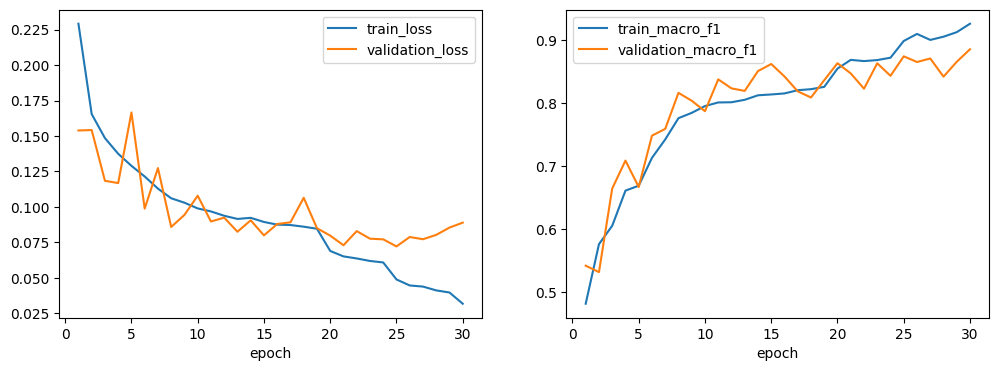

,precision,recall,f1,support
Center,0.953317,0.904429,0.928230,429.0
Donut,0.860000,0.767857,0.811321,56.0
Edge-Loc,0.883002,0.770713,0.823045,519.0
Edge-Ring,0.974280,0.978306,0.976289,968.0
Loc,0.817610,0.724234,0.768095,359.0
Random,0.934211,0.825581,0.876543,86.0
Scratch,0.885714,0.775000,0.826667,120.0
Near-full,1.000000,0.933333,0.965517,15.0
none,0.984832,0.995320,0.990048,14743.0


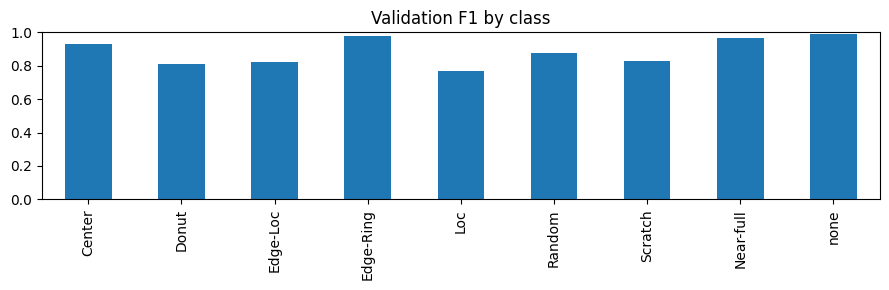

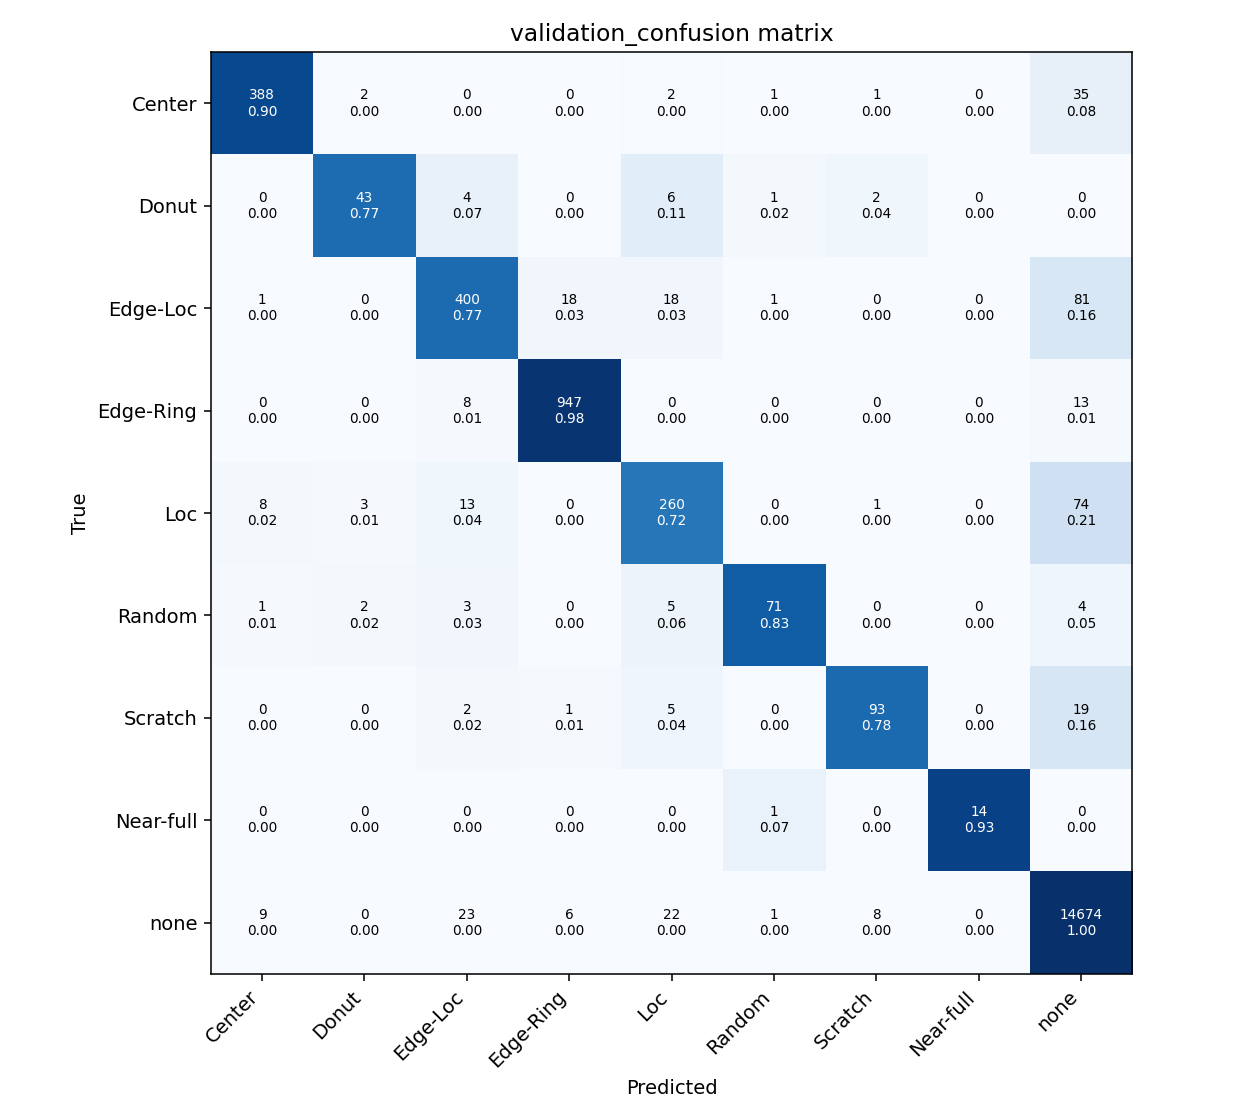

In [7]:
import matplotlib.pyplot as plt

results = load_experiment_results(ARTIFACT_ROOT)
results = results[
    (results.split_id == splits.split_id)
    & (results.code_version == code_version())
]
display(results.sort_values("validation_macro_f1", ascending=False))
EXPERIMENT_ID = (
    results.sort_values("validation_macro_f1", ascending=False)
    .iloc[0]
    .experiment_id
)
experiment_dir = ARTIFACT_ROOT / EXPERIMENT_ID
history = pd.read_csv(experiment_dir / "history.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history.plot(x="epoch", y=["train_loss", "validation_loss"], ax=axes[0])
history.plot(
    x="epoch", y=["train_macro_f1", "validation_macro_f1"], ax=axes[1]
)
plt.show()
metrics = read_json(experiment_dir / "metrics.json")
class_metrics = pd.DataFrame(metrics["validation"]["per_class"]).T
display(class_metrics)
class_metrics["f1"].plot.bar(
    title="Validation F1 by class", ylim=(0, 1), figsize=(9, 3)
)
plt.tight_layout()
plt.show()
display(Image(filename=str(experiment_dir / "confusion_matrix.png")))

## 실행 재개와 결과 보관

끊긴 경우 환경·데이터 셀부터 실행한 뒤 필요한 단계 셀을 다시 실행합니다. 동일 설정·분할·코드의 완료 실험은 건너뛰며 중단 실험은 처음부터 학습합니다. `artifacts/`는 Drive에 보존됩니다. 모델·CSV·PNG·로그 등 필요한 파일을 직접 로컬 PC로 내려받으세요.

전체 자동 실행은 `run_stage('all', splits, ARTIFACT_ROOT, BASE_CONFIG)`로도 가능합니다. 이는 최종 test 평가까지 포함합니다.